# Sales Data ETL Pipeline Using PostgreSQL and Python

This notebook follows the mini project brief: connect to PostgreSQL, extract sales data, clean and validate it, transform it, generate business insights, export results, and complete the advanced challenges.
## Objective

This project demonstrates how to build a complete ETL (Extract, Transform, Load) pipeline using Python, PostgreSQL, and Pandas.

The project covers:

- Connecting to PostgreSQL
- Extracting sales data
- Cleaning data
- Transforming data
- Performing business analysis
- Generating reports
- Exporting processed data
- Loading cleaned data back into PostgreSQL

---
Workflow

PostgreSQL
     │
     ▼
Extract Data
     │
     ▼
Clean Data
     │
     ▼
Transform Data
     │
     ▼
Analyze Data
     │
     ▼
Export Reports
     │
     ▼
Load Processed Data

## Step 1 - Install dependencies
## Run this once if any package is missing in your notebook environment.
If the required libraries are not installed, uncomment and run the following cell.


In [1]:
# Uncomment if necessary

# !pip install pandas
# !pip install sqlalchemy
# !pip install psycopg2-binary
# !pip install openpyxl
# !pip install matplotlib

## Step 2 - Import Required Libraries & notebook settings

In [1]:

from pathlib import Path
from urllib.parse import quote_plus
import os
from getpass import getpass
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")
from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


## Step 3 - PostgreSQL connection settings
 You can set these as environment variables, or edit the default values below.

In [28]:
# Cell 3 - PostgreSQL connection settings
# You can set these as environment variables, or edit the default values below.
DB_USER = os.getenv("POSTGRES_USER", "postgres")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD") or getpass("PostgreSQL password: ")
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB", "retail_db")

DATABASE_URL = (
    f"postgresql+psycopg2://{quote_plus(DB_USER)}:"
    f"{quote_plus(DB_PASSWORD)}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)
print(f"Engine created for database: {DB_NAME} on {DB_HOST}:{DB_PORT}")


PostgreSQL password:  ········


Engine created for database: retail_db on localhost:5432


## Step 4 - Test the database connection

In [30]:
with engine.connect() as conn:
    db_version = conn.execute(text("SELECT version();")).scalar()

print(db_version)

PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35227, 64-bit


## Optional sample database setup

Run the next cell if you do not already have the project tables in PostgreSQL. It creates the three tables from the brief and inserts the sample customers, products, and sales records.

## Step 5 - Create project tables and insert sample data

In [31]:
schema_and_sample_sql = [
    """
    CREATE TABLE IF NOT EXISTS customers (
        customer_id SERIAL PRIMARY KEY,
        customer_name VARCHAR(100),
        city VARCHAR(100),
        registration_date DATE
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS products (
        product_id SERIAL PRIMARY KEY,
        product_name VARCHAR(100),
        category VARCHAR(50),
        price NUMERIC(10,2)
    );
    """,
    """
    CREATE TABLE IF NOT EXISTS sales (
        sale_id SERIAL PRIMARY KEY,
        customer_id INT REFERENCES customers(customer_id),
        product_id INT REFERENCES products(product_id),
        quantity INT,
        sale_date DATE
    );
    """,
    """
    INSERT INTO customers (customer_id, customer_name, city, registration_date)
    VALUES
        (1, 'Abebe', 'Addis Ababa', '2024-01-05'),
        (2, 'Hana', 'Adama', '2024-02-11'),
        (3, 'Samuel', 'Hawassa', '2024-03-18')
    ON CONFLICT (customer_id) DO UPDATE SET
        customer_name = EXCLUDED.customer_name,
        city = EXCLUDED.city,
        registration_date = EXCLUDED.registration_date;
    """,
    """
    INSERT INTO products (product_id, product_name, category, price)
    VALUES
        (1, 'Laptop', 'Electronics', 800.00),
        (2, 'Mouse', 'Electronics', 15.00),
        (3, 'Chair', 'Furniture', 120.00)
    ON CONFLICT (product_id) DO UPDATE SET
        product_name = EXCLUDED.product_name,
        category = EXCLUDED.category,
        price = EXCLUDED.price;
    """,
    """
    INSERT INTO sales (sale_id, customer_id, product_id, quantity, sale_date)
    VALUES
        (1, 1, 1, 2, CURRENT_DATE - INTERVAL '2 days'),
        (2, 2, 2, 5, CURRENT_DATE - INTERVAL '1 day'),
        (3, 3, 3, 1, CURRENT_DATE)
    ON CONFLICT (sale_id) DO UPDATE SET
        customer_id = EXCLUDED.customer_id,
        product_id = EXCLUDED.product_id,
        quantity = EXCLUDED.quantity,
        sale_date = EXCLUDED.sale_date;
    """,
    """
    SELECT setval(
        pg_get_serial_sequence('customers', 'customer_id'),
        COALESCE((SELECT MAX(customer_id) FROM customers), 1),
        true
    );
    """,
    """
    SELECT setval(
        pg_get_serial_sequence('products', 'product_id'),
        COALESCE((SELECT MAX(product_id) FROM products), 1),
        true
    );
    """,
    """
    SELECT setval(
        pg_get_serial_sequence('sales', 'sale_id'),
        COALESCE((SELECT MAX(sale_id) FROM sales), 1),
        true
    );
    """,
]

with engine.begin() as conn:
    for statement in schema_and_sample_sql:
        conn.execute(text(statement))

print("Tables are ready and sample data has been loaded.")


Tables are ready and sample data has been loaded.


## Step 6 - Extract joined sales data from PostgreSQL

In [32]:
sales_query = """
SELECT
    s.sale_id,
    s.sale_date,
    c.customer_id,
    c.customer_name,
    c.city,
    c.registration_date,
    p.product_id,
    p.product_name,
    p.category,
    p.price,
    s.quantity
FROM sales AS s
JOIN customers AS c
    ON s.customer_id = c.customer_id
JOIN products AS p
    ON s.product_id = p.product_id
ORDER BY s.sale_date, s.sale_id;
"""

df = pd.read_sql(sales_query, engine)

display(df.head())
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


,sale_id,sale_date,customer_id,customer_name,city,registration_date,product_id,product_name,category,price,quantity
0,1,2026-06-26,1,Abebe,Addis Ababa,2024-01-05,1,Laptop,Electronics,800.00,2
1,2,2026-06-27,2,Hana,Adama,2024-02-11,2,Mouse,Electronics,15.00,5
2,3,2026-06-28,3,Samuel,Hawassa,2024-03-18,3,Chair,Furniture,120.00,1


Rows: 3
Columns: 11


## Step 7 - Explore the extracted data

In [33]:
print("Dataset shape:", df.shape)
print("\nData types:")
df.info()

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(dropna=True),
})

display(profile)
display(df.describe(include="all").transpose())

Dataset shape: (3, 11)

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sale_id            3 non-null      int64  
 1   sale_date          3 non-null      object 
 2   customer_id        3 non-null      int64  
 3   customer_name      3 non-null      str    
 4   city               3 non-null      str    
 5   registration_date  3 non-null      object 
 6   product_id         3 non-null      int64  
 7   product_name       3 non-null      str    
 8   category           3 non-null      str    
 9   price              3 non-null      float64
 10  quantity           3 non-null      int64  
dtypes: float64(1), int64(4), object(2), str(4)
memory usage: 396.0+ bytes


,dtype,missing_values,unique_values
sale_id,int64,0,3
sale_date,object,0,3
customer_id,int64,0,3
customer_name,str,0,3
city,str,0,3
registration_date,object,0,3
product_id,int64,0,3
product_name,str,0,3
category,str,0,2
price,float64,0,3


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sale_id,3.00,NaN,NaN,NaN,2.00,1.00,1.00,1.50,2.00,2.50,3.00
sale_date,3,3,2026-06-26,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,3.00,NaN,NaN,NaN,2.00,1.00,1.00,1.50,2.00,2.50,3.00
customer_name,3,3,Abebe,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,3,3,Addis Ababa,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
registration_date,3,3,2024-01-05,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,3.00,NaN,NaN,NaN,2.00,1.00,1.00,1.50,2.00,2.50,3.00
product_name,3,3,Laptop,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,3,2,Electronics,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,3.00,NaN,NaN,NaN,311.67,426.16,15.00,67.50,120.00,460.00,800.00


## Step 8 - Build a reusable data quality report

In [34]:
def build_data_quality_report(data: pd.DataFrame) -> pd.DataFrame:
    checks = []

    def add_check(rule: str, failed_rows: int, details: str, status: str | None = None) -> None:
        if status is None:
            status = "PASS" if failed_rows == 0 else "FAIL"
        checks.append({
            "rule": rule,
            "status": status,
            "failed_rows": int(failed_rows),
            "details": details,
        })

    add_check("Total rows", 0, f"Dataset contains {len(data)} rows.", status="INFO")

    duplicate_count = data.duplicated().sum()
    add_check("Duplicate records", duplicate_count, f"Found {duplicate_count} duplicate rows.")

    for column in data.columns:
        null_count = data[column].isna().sum()
        add_check(f"Null values in {column}", null_count, f"Found {null_count} null values in {column}.")

    if "quantity" in data.columns:
        quantity = pd.to_numeric(data["quantity"], errors="coerce")
        negative_quantity_count = (quantity < 0).sum()
        add_check("Negative quantities", negative_quantity_count, f"Found {negative_quantity_count} rows with quantity < 0.")

    if "price" in data.columns:
        price = pd.to_numeric(data["price"], errors="coerce")
        negative_price_count = (price < 0).sum()
        add_check("Negative prices", negative_price_count, f"Found {negative_price_count} rows with price < 0.")

    if "sale_date" in data.columns:
        parsed_dates = pd.to_datetime(data["sale_date"], errors="coerce")
        invalid_date_count = (data["sale_date"].notna() & parsed_dates.isna()).sum()
        add_check("Invalid sale dates", invalid_date_count, f"Found {invalid_date_count} invalid non-null sale dates.")

    return pd.DataFrame(checks)

raw_quality_report = build_data_quality_report(df)
display(raw_quality_report)


,rule,status,failed_rows,details
0,Total rows,INFO,0,Dataset contains 3 rows.
1,Duplicate records,PASS,0,Found 0 duplicate rows.
2,Null values in sale_id,PASS,0,Found 0 null values in sale_id.
3,Null values in sale_date,PASS,0,Found 0 null values in sale_date.
4,Null values in customer_id,PASS,0,Found 0 null values in customer_id.
5,Null values in customer_name,PASS,0,Found 0 null values in customer_name.
6,Null values in city,PASS,0,Found 0 null values in city.
7,Null values in registration_date,PASS,0,Found 0 null values in registration_date.
8,Null values in product_id,PASS,0,Found 0 null values in product_id.
9,Null values in product_name,PASS,0,Found 0 null values in product_name.


## Step 9 - Clean the sales data

In [35]:
def clean_sales_data(data: pd.DataFrame) -> pd.DataFrame:
    cleaned = data.copy()
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)

    cleaned["quantity"] = pd.to_numeric(cleaned["quantity"], errors="coerce").fillna(1)
    cleaned["price"] = pd.to_numeric(cleaned["price"], errors="coerce")

    text_columns = ["customer_name", "city", "product_name", "category"]
    for column in text_columns:
        cleaned[column] = (
            cleaned[column]
            .fillna("Unknown")
            .astype(str)
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
            .str.title()
        )
        cleaned[column] = cleaned[column].replace("", "Unknown")

    cleaned["sale_date"] = pd.to_datetime(cleaned["sale_date"], errors="coerce")
    cleaned["registration_date"] = pd.to_datetime(cleaned["registration_date"], errors="coerce")

    cleaned = cleaned[
        (cleaned["quantity"] > 0)
        & (cleaned["price"] >= 0)
        & cleaned["sale_date"].notna()
        & cleaned["price"].notna()
    ].reset_index(drop=True)

    cleaned["quantity"] = cleaned["quantity"].astype(int)
    return cleaned

rows_before = len(df)
df_clean = clean_sales_data(df)
rows_after = len(df_clean)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

display(df_clean)

Rows before cleaning: 3
Rows after cleaning: 3
Rows removed: 0


,sale_id,sale_date,customer_id,customer_name,city,registration_date,product_id,product_name,category,price,quantity
0,1,2026-06-26,1,Abebe,Addis Ababa,2024-01-05,1,Laptop,Electronics,800.00,2
1,2,2026-06-27,2,Hana,Adama,2024-02-11,2,Mouse,Electronics,15.00,5
2,3,2026-06-28,3,Samuel,Hawassa,2024-03-18,3,Chair,Furniture,120.00,1


## Step 10 - Transform the cleaned data

In [80]:
from pandas.api.types import CategoricalDtype

sales_category_order = CategoricalDtype(categories=["Low", "Medium", "High"], ordered=True)

def sales_category(amount: float) -> str:
    if amount >= 1000:
        return "High"
    if amount >= 500:
        return "Medium"
    return "Low"

df_clean["total_sale"] = df_clean["price"] * df_clean["quantity"]
df_clean["year"] = df_clean["sale_date"].dt.year
df_clean["month"] = df_clean["sale_date"].dt.month
df_clean["month_name"] = df_clean["sale_date"].dt.month_name()
df_clean["day_name"] = df_clean["sale_date"].dt.day_name()
df_clean["day"] = df_clean["sale_date"].dt.day
df_clean["sales_category"] = df_clean["total_sale"].apply(sales_category).astype(sales_category_order)

display(df_clean.head())


,sale_id,sale_date,customer_id,customer_name,city,registration_date,product_id,product_name,category,price,quantity,total_sale,year,month,month_name,day,sales_category,is_weekend,day_name
0,1,2026-06-26,1,Abebe,Addis Ababa,2024-01-05,1,Laptop,Electronics,800.00,2,"1,600.00",2026,6,June,26,High,False,Friday
1,2,2026-06-27,2,Hana,Adama,2024-02-11,2,Mouse,Electronics,15.00,5,75.00,2026,6,June,27,Low,False,Saturday
2,3,2026-06-28,3,Samuel,Hawassa,2024-03-18,3,Chair,Furniture,120.00,1,120.00,2026,6,June,28,Low,False,Sunday


## Business Analysis

In this section we will answer important business questions such as:

- What products sell the most?
- Which category generates the highest revenue?
- Which city has the highest sales?
- Who are the best customers?
- How does revenue change over time?

In [52]:
print("Total Revenue")

df_clean["total_sale"].sum()

print("Average Sale")

df_clean["total_sale"].mean()

print("Number of Customers")

df_clean["customer_name"].nunique()

print("Number of Products")

df_clean["product_name"].nunique()

print("Top Selling Products")

top_products = (
    df_clean.groupby("product_name")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

top_products

Total Revenue
Average Sale
Number of Customers
Number of Products
Top Selling Products


product_name
Mouse     5
Laptop    2
Chair     1
Name: quantity, dtype: int64

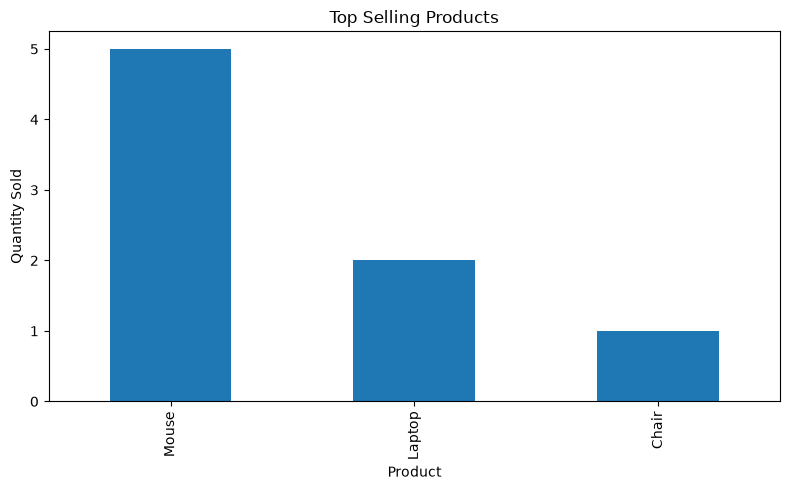

In [53]:
top_products.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.tight_layout()
plt.show()

## Revenue by Product Category

In [54]:
revenue_category = (
    df_clean.groupby("category")["total_sale"]
      .sum()
      .sort_values(ascending=False)
)

revenue_category

category
Electronics   1,675.00
Furniture       120.00
Name: total_sale, dtype: float64

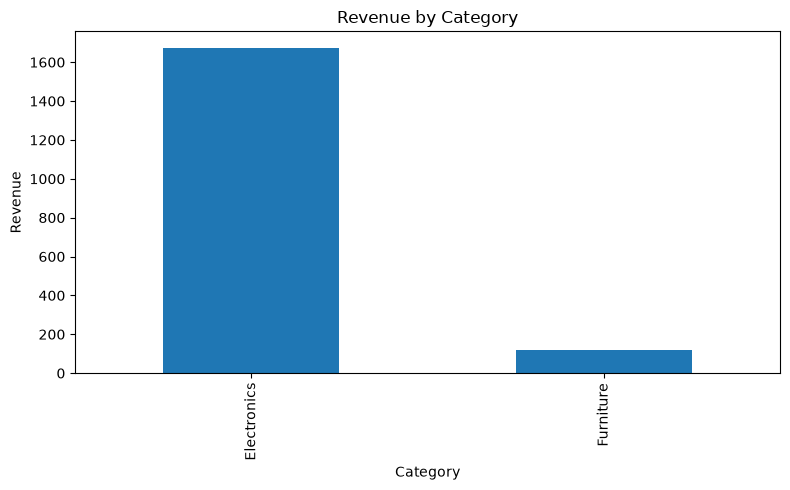

In [55]:
revenue_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Revenue by City

In [57]:
city_sales = (
    df_clean.groupby("city")["total_sale"]
      .sum()
      .sort_values(ascending=False)
)

city_sales

city
Addis Ababa   1,600.00
Hawassa         120.00
Adama            75.00
Name: total_sale, dtype: float64

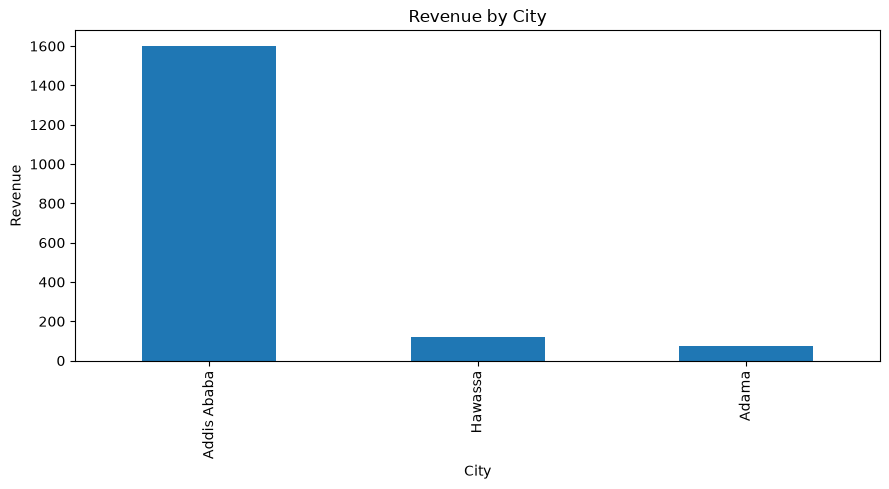

In [58]:
city_sales.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Top Customers

In [59]:
top_customers = (
    df_clean.groupby("customer_name")["total_sale"]
      .sum()
      .sort_values(ascending=False)
)

top_customers.head(10)

customer_name
Abebe    1,600.00
Samuel     120.00
Hana        75.00
Name: total_sale, dtype: float64

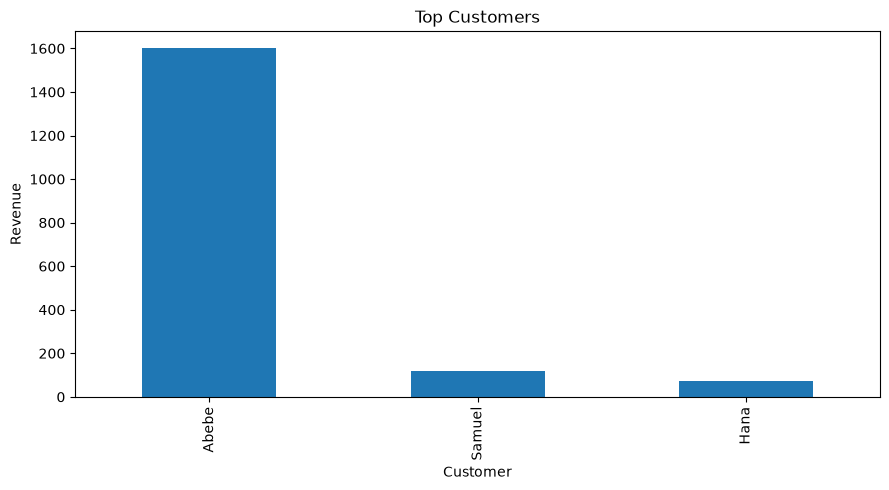

In [60]:
top_customers.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Top Customers")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Monthly Revenue Trend

In [62]:
monthly_sales = (
    df_clean.groupby("month_name")["total_sale"]
      .sum()
)

monthly_sales

month_name
June   1,795.00
Name: total_sale, dtype: float64

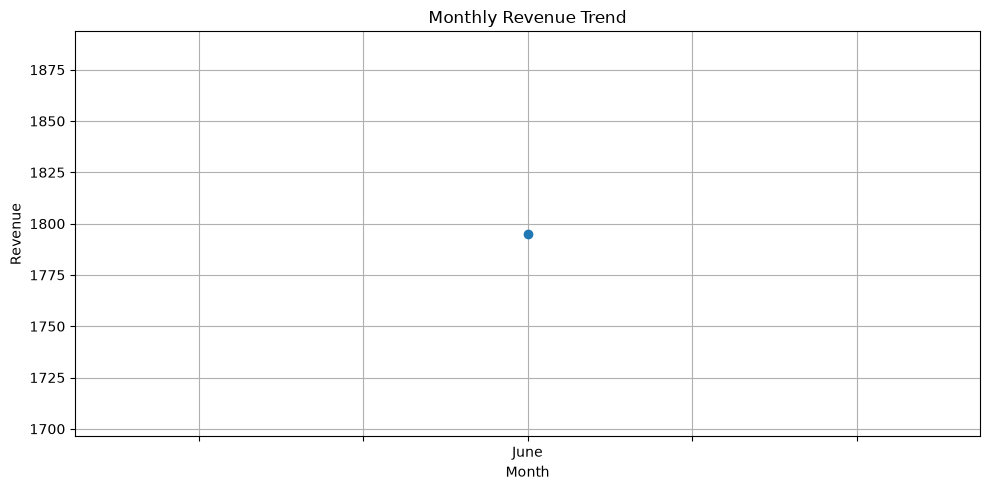

In [64]:
monthly_sales.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

## Sales Category Distribution

In [65]:
sales_category_count = (
    df_clean["sales_category"]
      .value_counts()
)

sales_category_count

sales_category
Low       2
High      1
Medium    0
Name: count, dtype: int64

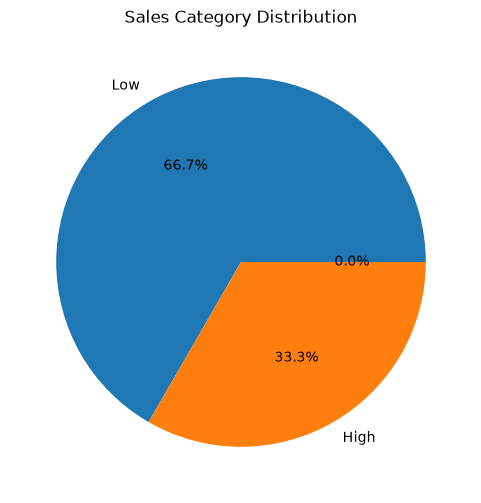

In [66]:
sales_category_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sales Category Distribution")
plt.ylabel("")

plt.show()

## Pivot Table

In [67]:
pivot = pd.pivot_table(
    df_clean,
    values="total_sale",
    index="city",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

pivot

category,Electronics,Furniture
city,,
Adama,75.00,0.00
Addis Ababa,"1,600.00",0.00
Hawassa,0.00,120.00


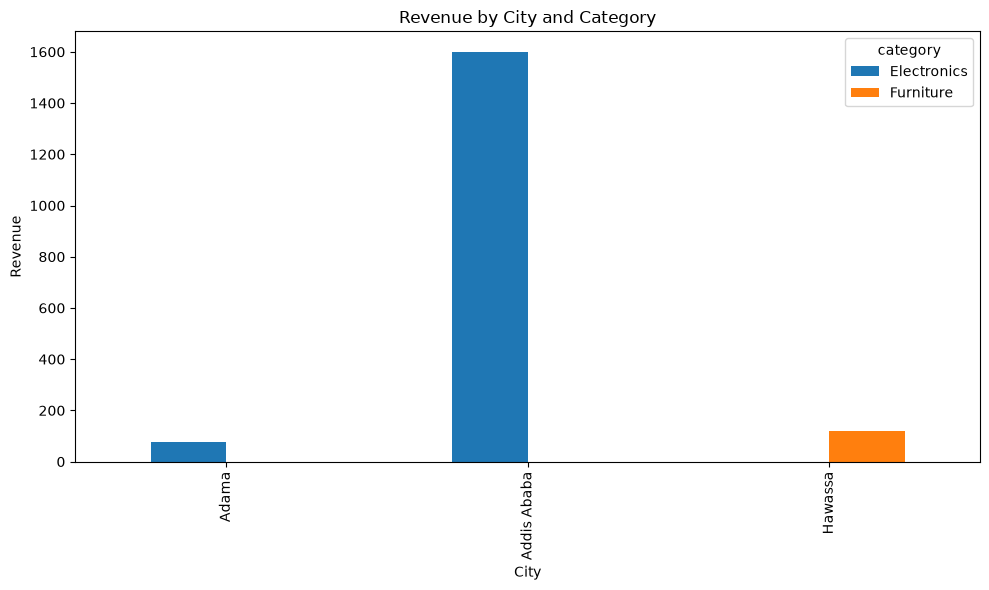

In [68]:
pivot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Revenue by City and Category")

plt.xlabel("City")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

## Highest Revenue Day

In [69]:
daily_sales = (
    df_clean.groupby("sale_date")["total_sale"]
      .sum()
      .sort_values(ascending=False)
)

daily_sales.head()

sale_date
2026-06-26   1,600.00
2026-06-28     120.00
2026-06-27      75.00
Name: total_sale, dtype: float64

## Weekend vs Weekday Sales

In [81]:

df_clean["is_weekend"] = df_clean["day_name"].isin(
    ["Saturday", "Sunday"]
)

df_clean.head()

weekend_sales = (
    df_clean.groupby("is_weekend")["total_sale"]
      .sum()
)

weekend_sales


is_weekend
False   1,600.00
True      195.00
Name: total_sale, dtype: float64

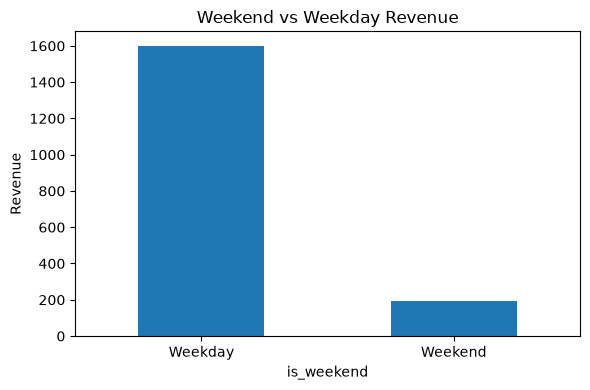

In [82]:
weekend_sales.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Weekend vs Weekday Revenue")

plt.xticks(
    [0,1],
    ["Weekday","Weekend"],
    rotation=0
)

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

## Sales Summary

In [83]:
summary = pd.DataFrame({

    "Metric":[

        "Total Revenue",

        "Average Revenue",

        "Maximum Sale",

        "Minimum Sale",

        "Number of Customers",

        "Number of Products"

    ],

    "Value":[

        df_clean["total_sale"].sum(),

        df_clean["total_sale"].mean(),

        df_clean["total_sale"].max(),

        df_clean["total_sale"].min(),

        df_clean["customer_name"].nunique(),

        df_clean["product_name"].nunique()

    ]

})

summary

,Metric,Value
0,Total Revenue,"1,795.00"
1,Average Revenue,598.33
2,Maximum Sale,"1,600.00"
3,Minimum Sale,75.00
4,Number of Customers,3.00
5,Number of Products,3.00


In [84]:
summary.style.set_caption("Executive Sales Summary")

,Metric,Value
0,Total Revenue,1795.000000
1,Average Revenue,598.333333
2,Maximum Sale,1600.000000
3,Minimum Sale,75.000000
4,Number of Customers,3.000000
5,Number of Products,3.000000


## Step 11 - Business analysis and insights

In [85]:
top_products = (
    df_clean.groupby("product_name", as_index=False)["quantity"]
    .sum()
    .sort_values("quantity", ascending=False)
)

revenue_by_category = (
    df_clean.groupby("category", as_index=False)["total_sale"]
    .sum()
    .sort_values("total_sale", ascending=False)
)

revenue_by_city = (
    df_clean.groupby("city", as_index=False)["total_sale"]
    .sum()
    .sort_values("total_sale", ascending=False)
)

top_customers = (
    df_clean.groupby("customer_name", as_index=False)["total_sale"]
    .sum()
    .sort_values("total_sale", ascending=False)
    .head(10)
)

monthly_revenue = (
    df_clean.assign(month_start=df_clean["sale_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month_start", as_index=False)["total_sale"]
    .sum()
    .sort_values("month_start")
)

sales_pivot = pd.pivot_table(
    df_clean,
    values="total_sale",
    index="city",
    columns="category",
    aggfunc="sum",
    fill_value=0,
)

display(top_products)
display(revenue_by_category)
display(revenue_by_city)
display(top_customers)
display(monthly_revenue)
display(sales_pivot)


,product_name,quantity
2,Mouse,5
1,Laptop,2
0,Chair,1


,category,total_sale
0,Electronics,"1,675.00"
1,Furniture,120.00


,city,total_sale
1,Addis Ababa,"1,600.00"
2,Hawassa,120.00
0,Adama,75.00


,customer_name,total_sale
0,Abebe,"1,600.00"
2,Samuel,120.00
1,Hana,75.00


,month_start,total_sale
0,2026-06-01,"1,795.00"


category,Electronics,Furniture
city,,
Adama,75.00,0.00
Addis Ababa,"1,600.00",0.00
Hawassa,0.00,120.00


## Business Analysis

In this section we will answer important business questions such as:

- What products sell the most?
- Which category generates the highest revenue?
- Which city has the highest sales?
- Who are the best customers?
- How does revenue change over time?

## Step 12 - Generate an executive summary report

In [86]:
report = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Sale",
        "Max Sale",
        "Min Sale",
        "Number of Customers",
        "Number of Orders",
        "Total Units Sold",
    ],
    "Value": [
        df_clean["total_sale"].sum(),
        df_clean["total_sale"].mean(),
        df_clean["total_sale"].max(),
        df_clean["total_sale"].min(),
        df_clean["customer_name"].nunique(),
        df_clean["sale_id"].nunique(),
        df_clean["quantity"].sum(),
    ],
})

display(report)


,Metric,Value
0,Total Revenue,"1,795.00"
1,Average Sale,598.33
2,Max Sale,"1,600.00"
3,Min Sale,75.00
4,Number of Customers,3.00
5,Number of Orders,3.00
6,Total Units Sold,8.00


## Step 13 - Run data quality checks after cleaning and transformation

In [39]:
clean_quality_report = build_data_quality_report(df_clean)
display(clean_quality_report)

,rule,status,failed_rows,details
0,Total rows,INFO,0,Dataset contains 3 rows.
1,Duplicate records,PASS,0,Found 0 duplicate rows.
2,Null values in sale_id,PASS,0,Found 0 null values in sale_id.
3,Null values in sale_date,PASS,0,Found 0 null values in sale_date.
4,Null values in customer_id,PASS,0,Found 0 null values in customer_id.
5,Null values in customer_name,PASS,0,Found 0 null values in customer_name.
6,Null values in city,PASS,0,Found 0 null values in city.
7,Null values in registration_date,PASS,0,Found 0 null values in registration_date.
8,Null values in product_id,PASS,0,Found 0 null values in product_id.
9,Null values in product_name,PASS,0,Found 0 null values in product_name.


## Step 14 - Export cleaned data and reports

In [40]:
cleaned_csv_path = OUTPUT_DIR / "cleaned_sales_data.csv"
json_path = OUTPUT_DIR / "sales_data.json"
excel_path = OUTPUT_DIR / "sales_data.xlsx"
summary_report_path = OUTPUT_DIR / "sales_report.csv"
raw_quality_path = OUTPUT_DIR / "raw_data_quality_report.csv"
clean_quality_path = OUTPUT_DIR / "clean_data_quality_report.csv"
top_products_path = OUTPUT_DIR / "top_products.csv"
revenue_category_path = OUTPUT_DIR / "revenue_by_category.csv"
revenue_city_path = OUTPUT_DIR / "revenue_by_city.csv"
monthly_revenue_path = OUTPUT_DIR / "monthly_revenue.csv"

# Main exports from the project brief.
df_clean.to_csv(cleaned_csv_path, index=False)
df_clean.to_json(json_path, orient="records", indent=4, date_format="iso")
df_clean.to_excel(excel_path, index=False)
report.to_csv(summary_report_path, index=False)

# Extra exports for analysis and data quality.
raw_quality_report.to_csv(raw_quality_path, index=False)
clean_quality_report.to_csv(clean_quality_path, index=False)
top_products.to_csv(top_products_path, index=False)
revenue_by_category.to_csv(revenue_category_path, index=False)
revenue_by_city.to_csv(revenue_city_path, index=False)
monthly_revenue.to_csv(monthly_revenue_path, index=False)

exported_files = [
    cleaned_csv_path,
    json_path,
    excel_path,
    summary_report_path,
    raw_quality_path,
    clean_quality_path,
    top_products_path,
    revenue_category_path,
    revenue_city_path,
    monthly_revenue_path,
]

for path in exported_files:
    print(path.resolve())


C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject - Sales\outputs\cleaned_sales_data.csv
C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject - Sales\outputs\sales_data.json
C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject - Sales\outputs\sales_data.xlsx
C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject - Sales\outputs\sales_report.csv
C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject - Sales\outputs\raw_data_quality_report.csv
C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject - Sales\outputs\clean_data_quality

## Step 15 - Advanced challenge: incremental load for today's sales

In [41]:
today_sales_query = """
SELECT
    s.sale_id,
    s.sale_date,
    c.customer_id,
    c.customer_name,
    c.city,
    c.registration_date,
    p.product_id,
    p.product_name,
    p.category,
    p.price,
    s.quantity
FROM sales AS s
JOIN customers AS c
    ON s.customer_id = c.customer_id
JOIN products AS p
    ON s.product_id = p.product_id
WHERE s.sale_date = CURRENT_DATE
ORDER BY s.sale_id;
"""

today_sales = pd.read_sql(today_sales_query, engine)
today_sales_clean = clean_sales_data(today_sales) if not today_sales.empty else today_sales.copy()

print(f"Today's extracted rows: {len(today_sales)}")
display(today_sales_clean)


Today's extracted rows: 1


,sale_id,sale_date,customer_id,customer_name,city,registration_date,product_id,product_name,category,price,quantity
0,3,2026-06-28,3,Samuel,Hawassa,2024-03-18,3,Chair,Furniture,120.00,1


## Step 16 - Advanced challenge: load processed data back into PostgreSQL

In [42]:
df_clean.to_sql(
    "processed_sales",
    engine,
    if_exists="replace",
    index=False,
)

with engine.connect() as conn:
    processed_count = conn.execute(text("SELECT COUNT(*) FROM processed_sales;")).scalar()

print(f"processed_sales table refreshed with {processed_count} rows.")


processed_sales table refreshed with 3 rows.


## Step 17 - Final pipeline summary

In [43]:
print("Sales ETL pipeline completed.")
print(f"Clean rows: {len(df_clean)}")
print(f"Total revenue: {df_clean['total_sale'].sum():,.2f}")
print(f"Export folder: {OUTPUT_DIR.resolve()}")

display(report)

Sales ETL pipeline completed.
Clean rows: 3
Total revenue: 1,795.00
Export folder: C:\Users\craft\OneDrive\Pictures\Data Engineering Acclerator Program\Module 1 - Data Engineering Fundamentals & Python\MiniProject - Sales\outputs


,Metric,Value
0,Total Revenue,"1,795.00"
1,Average Sale,598.33
2,Max Sale,"1,600.00"
3,Min Sale,75.00
4,Number of Customers,3.00
5,Number of Orders,3.00
6,Total Units Sold,8.00


# Project Conclusion

The ETL pipeline was successfully completed.

### Accomplishments

✔ Connected to PostgreSQL

✔ Extracted sales data

✔ Cleaned the dataset

✔ Validated data quality

✔ Created calculated fields

✔ Performed business analysis

✔ Built visualizations

✔ Generated reports

✔ Exported data to CSV, Excel, and JSON

✔ Loaded processed data back into PostgreSQL

The processed dataset is now ready for dashboards, reporting, and further analytics.

# Skills Demonstrated

- Python
- Pandas
- PostgreSQL
- SQL
- SQLAlchemy
- ETL Pipeline Development
- Data Cleaning
- Data Transformation
- Data Quality Validation
- Data Visualization
- Reporting
- Data Export

In [87]:
print("🎉 Congratulations!")
print("The Sales Data ETL Pipeline has been completed successfully.")

🎉 Congratulations!
The Sales Data ETL Pipeline has been completed successfully.


In [88]:
# Display the first 10 processed records

df_clean.head(10)

,sale_id,sale_date,customer_id,customer_name,city,registration_date,product_id,product_name,category,price,quantity,total_sale,year,month,month_name,day,sales_category,is_weekend,day_name
0,1,2026-06-26,1,Abebe,Addis Ababa,2024-01-05,1,Laptop,Electronics,800.00,2,"1,600.00",2026,6,June,26,High,False,Friday
1,2,2026-06-27,2,Hana,Adama,2024-02-11,2,Mouse,Electronics,15.00,5,75.00,2026,6,June,27,Low,True,Saturday
2,3,2026-06-28,3,Samuel,Hawassa,2024-03-18,3,Chair,Furniture,120.00,1,120.00,2026,6,June,28,Low,True,Sunday


In [91]:
# Save the processed DataFrame as a pickle file

df.to_pickle("processed_sales.pkl")

print("Pickle file saved successfully.")

Pickle file saved successfully.


In [92]:
# Record pipeline execution time

from datetime import datetime

end_time = datetime.now()

print("Pipeline completed at:", end_time)

Pipeline completed at: 2026-06-28 18:28:20.566475
